In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from matplotlib.ticker import AutoMinorLocator
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

Remove proteins with low plddt, are membrane proteins and/or signal peptide

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]


print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


## Supplement Fig 5A

*Create 2D histogram of stability metrices and melting point against Protein half-life for bottleneck proteins in AE-MS dataset

In [5]:
def calculate_hub_stability_correlations(df, hub_threshold_quantile=0.90):
    print("="*90)
    print("CORRELATION ANALYSIS: Degree Centrality Hubs (MS/IPMS) vs Protein Stability")
    print("="*90)

    # Prepare full dataset
    base_cols = ['degree_centrality', 'Villen_halflife_min']
    stability_info = [
        ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
        ('cagiada-dG', 'Cagiada ΔG'),
        ('Rosetta_best_total_score', 'Rosetta Total Score'),
    ]

    # Special handling for meltome
    meltome_data = df[df['meltome-fit-R2'] >= 0.9].copy()
    if len(meltome_data) > 10:
        stability_info.append(('meltome-melting-point', 'Meltome Melting Point (°C)'))
        print(f"Meltome data (R² ≥ 0.9): {len(meltome_data)} proteins")
    else:
        print("Warning: Not enough high-quality meltome data (R² ≥ 0.9)")

    # Full data + hubs
    data = df[base_cols + [col for col, _ in stability_info]].dropna(subset=base_cols)
    hubs = data[data['degree_centrality'] >= data['degree_centrality'].quantile(hub_threshold_quantile)]

    print(f"\nTotal proteins with half-life: {len(data)}")
    print(f"Degree hubs (top 10%): {len(hubs)}")

    for stab_col, stab_name in stability_info:
        if stab_col not in data.columns:
            print(f"\nSkipping {stab_name} (column missing)")
            continue

        # Use filtered meltome only if it's that metric
        if stab_col == 'meltome-melting-point':
            current_data = meltome_data[[stab_col, 'Villen_halflife_min']].dropna()
            current_hubs = hubs[hubs.index.isin(meltome_data.index)]
        else:
            current_data = data[['Villen_halflife_min', stab_col]].dropna()
            current_hubs = hubs[[ 'Villen_halflife_min', stab_col]].dropna()

        print(f"\n→ {stab_name}")
        print(f"   n (all) = {len(current_data)}, n (hubs) = {len(current_hubs)}")

        # Spearman
        rho, p = spearmanr(current_data['Villen_halflife_min'], current_data[stab_col])
        print(f"   Spearman (all):  ρ = {rho:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            rho_h, p_h = spearmanr(current_hubs['Villen_halflife_min'], current_hubs[stab_col])
            print(f"   Spearman (hubs): ρ = {rho_h:+.3f}, p = {p_h:.2g}")
        
        # Pearson on log(t½)
        log_t12 = np.log10(current_data['Villen_halflife_min'])
        r, p = pearsonr(log_t12, current_data[stab_col])
        print(f"   Pearson log(t½) (all):  r = {r:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            log_t12_h = np.log10(current_hubs['Villen_halflife_min'])
            r_h, p_h = pearsonr(log_t12_h, current_hubs[stab_col])
            print(f"   Pearson log(t½) (hubs): r = {r_h:+.3f}, p = {p_h:.2g}")

# RUN IT
calculate_hub_stability_correlations(filtered_nodes, hub_threshold_quantile=0.90)

CORRELATION ANALYSIS: Degree Centrality Hubs (MS/IPMS) vs Protein Stability
Meltome data (R² ≥ 0.9): 1328 proteins

Total proteins with half-life: 1825
Degree hubs (top 10%): 197

→ Ghosh-Dill ΔG
   n (all) = 1824, n (hubs) = 197
   Spearman (all):  ρ = +0.040, p = 0.087
   Spearman (hubs): ρ = +0.344, p = 7.7e-07
   Pearson log(t½) (all):  r = +0.012, p = 0.62
   Pearson log(t½) (hubs): r = +0.229, p = 0.0012

→ Cagiada ΔG
   n (all) = 1824, n (hubs) = 197
   Spearman (all):  ρ = -0.055, p = 0.019
   Spearman (hubs): ρ = +0.268, p = 0.00014
   Pearson log(t½) (all):  r = -0.081, p = 0.00054
   Pearson log(t½) (hubs): r = +0.197, p = 0.0056

→ Rosetta Total Score
   n (all) = 1824, n (hubs) = 197
   Spearman (all):  ρ = -0.010, p = 0.68
   Spearman (hubs): ρ = +0.332, p = 1.9e-06
   Pearson log(t½) (all):  r = -0.027, p = 0.26
   Pearson log(t½) (hubs): r = +0.210, p = 0.003

→ Meltome Melting Point (°C)
   n (all) = 1176, n (hubs) = 143
   Spearman (all):  ρ = +0.256, p = 4.3e-19
   S

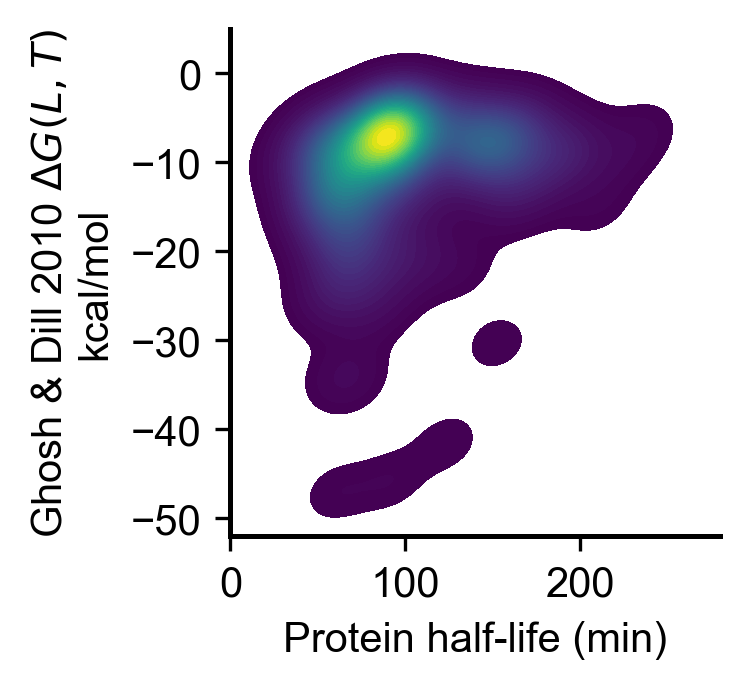

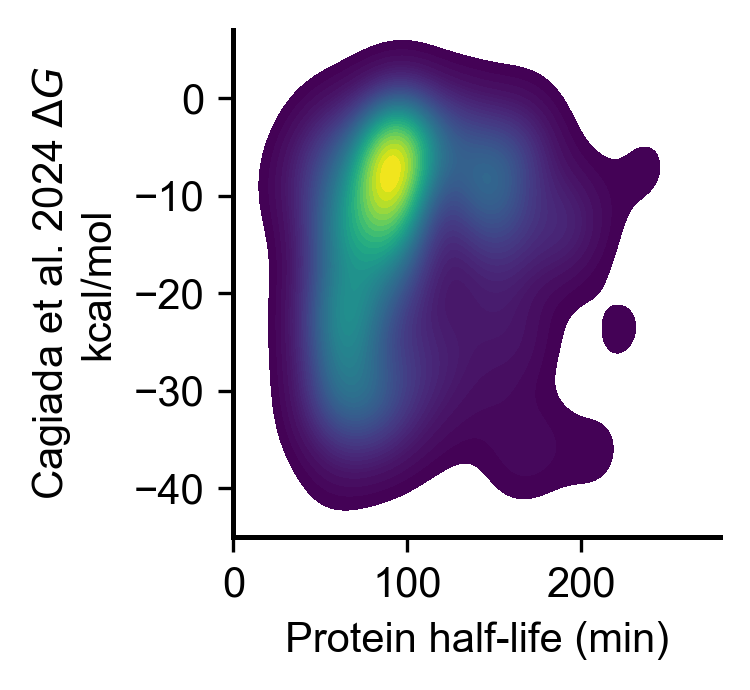

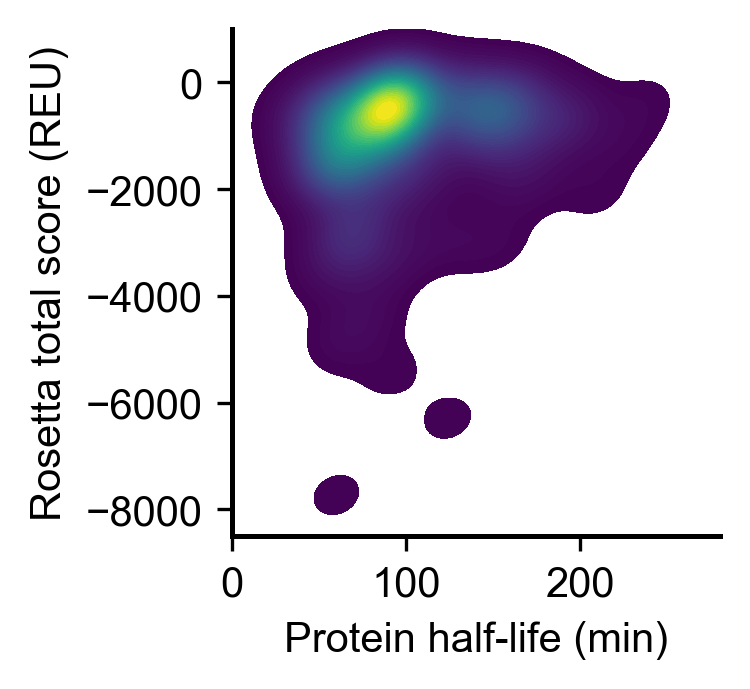

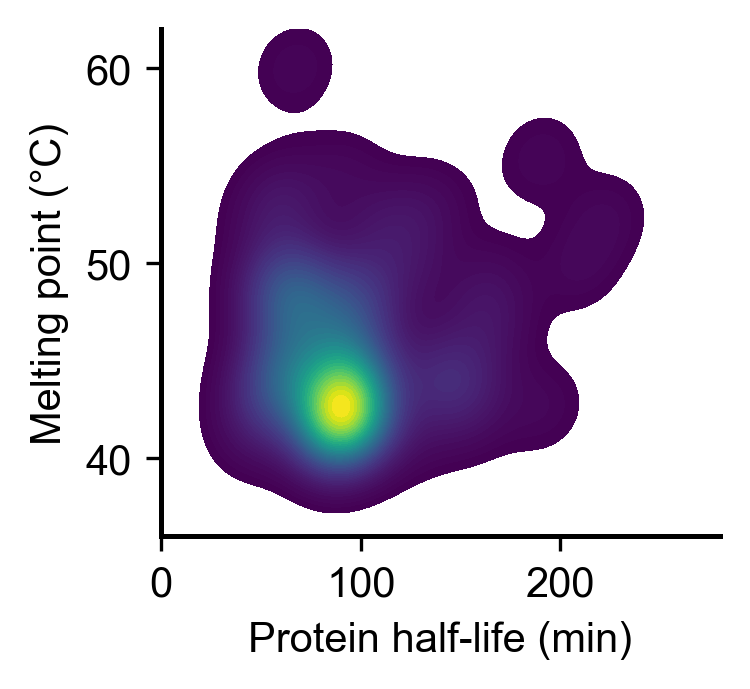

In [6]:
# Prepare data
plot_data = filtered_nodes.copy()

# Filter meltome strictly
meltome_hq = plot_data[plot_data['meltome-fit-R2'] >= 0.9]

def plot_hub_scatter(ax, data, x, y, ylabel, title):
    hubs = data[data['degree_centrality'] >= data['degree_centrality'].quantile(0.9)]

    sns.kdeplot(
        data=hubs,
        x=x,
        y=y,
        fill=True,
        cmap="viridis",
        levels=50,
        thresh=0.02,
        ax=ax
    )
    
    #ax.set_xscale('log')
    ax.set_xlim(1, 280)
    #ax.minorticks_off()
    ax.set_xticks([0, 100, 200])
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatterSciNotation())
    ax.set_xlabel('Protein half-life (min)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    sns.despine(ax=ax, trim=False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Ghosh–Dill ΔG 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='Ghosh-Dill-dG',
    ylabel=r"Ghosh & Dill 2010 $ΔG(L,T)$" + "\nkcal/mol",
    title=''
)
ax.set_ylim(-52, 5)
ax.set_yticks([0, -10, -20, -30, -40, -50])
plt.tight_layout()
fig.savefig("Supp5-1).svg", dpi=300, bbox_inches='tight')
plt.show()
    
# Cagiada ΔG
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='cagiada-dG',
    ylabel=r"Cagiada et al. 2024 $ΔG$" + "\nkcal/mol",
    title=''
)
ax.set_ylim(-45, 7)
ax.set_yticks([0, -10, -20, -30, -40])
plt.tight_layout()
fig.savefig("Supp5-2.svg", dpi=300, bbox_inches='tight')
plt.show()

# Rosetta Total Score 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='Rosetta_best_total_score',
    ylabel='Rosetta total score (REU)',
    title=''
)
#ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(-8500, 1000)
ax.set_yticks([0, -2000, -4000, -6000, -8000])
plt.tight_layout()
fig.savefig("Supp5-3.svg", dpi=300, bbox_inches='tight')
plt.show()


# Meltome Tm 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    meltome_hq,
    x='Villen_halflife_min',
    y='meltome-melting-point',
    ylabel='Melting point (°C)',
    title=''
)
ax.set_ylim(36, 62)
ax.set_yticks([60, 50, 40])
#ax.set_xlim(30, 400)
#ax.set_xticks([10, 30, 100, 300])
#ax.get_xaxis().set_major_formatter(ticker.LogFormatterSciNotation())
plt.tight_layout()
fig.savefig("Supp5-4", dpi=300, bbox_inches='tight')
plt.show()